# Stan ADVI: Walking Through ELBO Space (Beta-Binomial)

This is the Stan analogue of `paper_vignettes/1d_gaussian_no_obs_advi_optimizer_space.ipynb`,
which visualizes PyMC's ADVI trajectory on top of exact objective level curves. PyMC's
optimizer is pure Python, so that notebook hooks directly into it and records `(mu, sigma)`
at every iteration.

Stan's ADVI is a compiled binary and does **not** expose its internal `(mu, sigma)` path --
its `diagnostic_file` only logs `(iter, time, ELBO)` at a coarse cadence (every 100 iterations
by default), never the variational parameters themselves. So instead we reconstruct the path:

1. Stan's mean-field ADVI works in an **unconstrained** space `z`, with `theta = sigmoid(z)`
   for this model's `real<lower=0,upper=1> theta`, and fits `q(z) = Normal(mu, sigma)`.
2. Stan's own posterior draws are generated as `theta_i = sigmoid(mu + sigma * eps_i)`,
   `eps_i ~ N(0,1)` -- so `z_i = logit(theta_i)` recovers the *exact* underlying unconstrained
   draws (logit is the exact inverse of sigmoid, no approximation). Their sample mean/std are
   then simple, unbiased estimates of Stan's actual internal `(mu, sigma)` at that point.
3. We replay one `grad100_default_rest` restart (seed 0) at increasing iteration budgets --
   the same "checkpoint" trick the random-restart pipeline itself uses -- but with a much
   larger `output_samples` (20,000 vs. the pipeline's default 1,000) so each reconstructed
   `(mu, sigma)` point carries much less sampling noise, and a schedule that's coarse early
   and dense near the end so the tail oscillation is well resolved without the cost of
   tracking every single iteration throughout.
4. **On the ELBO surface itself**: the example notebook's contours are a closed-form KL
   divergence between two Gaussians (`exact_kl`/`exact_kl_sigma` in `modulars/distributions.py`)
   -- only possible because that toy model has no observations, so its true posterior is
   exactly Gaussian. Our beta-binomial model has real data and a `sigmoid`-constrained
   parameter, so there's no closed form available; instead we compute the ELBO essentially
   exactly via 100-point Gauss-Hermite quadrature over the 1-D unconstrained integral --
   the natural numerical stand-in, bounded by quadrature error rather than Monte Carlo noise,
   but a genuinely different computation than the example notebook's formula.

The red-line reference from the main notebook (`best_mean`/`best_std` in `beta_config.json`,
`best_method: "numpyro"`) is *itself* the `(mu, sigma)` of the best NumPyro ADVI run recorded
for this model -- so it's a point we can plot directly on these same axes.

In [1]:
import os
import sys
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist, binom
from scipy.special import expit, logit

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR
while not (REPO_ROOT / "modulars").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise FileNotFoundError("Could not locate repo root containing modulars/")
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modulars.utils import load_config
from modulars.plot_rr import draw_trajectory, draw_contours

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'lines.linewidth': 1.1,
})
np.set_printoptions(precision=4, suppress=True)

STAN_BINARY = NOTEBOOK_DIR / "stan_beta_binomial"
STAN_DATA_JSON = NOTEBOOK_DIR / "stan_cmdstan_output" / "cmdstan_runs" / "stan_data.json"
if not STAN_BINARY.exists():
    raise FileNotFoundError(
        f"Expected the already-compiled {STAN_BINARY} from rr_stan_beta.ipynb's run; "
        "run that notebook first."
    )
if not STAN_DATA_JSON.exists():
    raise FileNotFoundError(f"Expected {STAN_DATA_JSON} from rr_stan_beta.ipynb's run.")

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Stan binary: {STAN_BINARY}")
print(f"Stan data: {STAN_DATA_JSON}")

Notebook dir: /Users/madelynandersen/Documents/VB Bakeoff/simpleVI/single_MC/1dbeta_binomial/random_restarts
Stan binary: /Users/madelynandersen/Documents/VB Bakeoff/simpleVI/single_MC/1dbeta_binomial/random_restarts/stan_beta_binomial
Stan data: /Users/madelynandersen/Documents/VB Bakeoff/simpleVI/single_MC/1dbeta_binomial/random_restarts/stan_cmdstan_output/cmdstan_runs/stan_data.json


In [2]:
config = load_config(NOTEBOOK_DIR.parent / "beta_config.json")

alpha_prior = float(config["alpha_prior"])
beta_prior = float(config["beta_prior"])
n_samples = int(config["n_samples"])
theta_like = float(config["theta_like"])

# same draw as rr_stan_beta.ipynb: modulars.distributions.binomial(n_samples, theta_like)
# defaults to seed=20
from modulars.distributions import binomial
y = int(binomial(n_samples, theta_like))
n_trials = n_samples

# best_mean/best_std ARE the unconstrained-space (mu, sigma) of the best recorded ADVI fit
# (see beta_config.json: best_method is "numpyro") -- no transform needed here, unlike in
# rr_stan_beta.ipynb where they get pushed through logistic_moments to theta-space.
mu_star = float(config["best_mean"])
sigma_star = float(config["best_std"])

print(f"n_trials={n_trials}, y={y}, alpha_prior={alpha_prior}, beta_prior={beta_prior}")
print(f"best (mu*, sigma*) = ({mu_star:.4f}, {sigma_star:.4f})  [best_method={config['best_method']!r}]")

# exact posterior (conjugate): theta | y ~ Beta(alpha_prior + y, beta_prior + n_trials - y)
alpha_post = alpha_prior + y
beta_post = beta_prior + n_trials - y
print(f"exact posterior: Beta({alpha_post}, {beta_post})")

n_trials=10, y=7, alpha_prior=0.5, beta_prior=0.6
best (mu*, sigma*) = (0.8212, 0.6695)  [best_method='numpyro']
exact posterior: Beta(7.5, 3.5999999999999996)


In [3]:
def log_joint_z(z):
    '''log p(y, theta(z)) + log|dtheta/dz| for theta = sigmoid(z).

    This is exactly the density ADVI works with in the unconstrained space:
    the original model density times the Jacobian of the constraining transform.
    '''
    theta = expit(z)
    log_jacobian = np.log(theta) + np.log1p(-theta)  # log(theta * (1 - theta))
    return (
        beta_dist.logpdf(theta, alpha_prior, beta_prior)
        + binom.logpmf(y, n_trials, theta)
        + log_jacobian
    )


_GH_NODES, _GH_WEIGHTS = np.polynomial.hermite.hermgauss(100)


def elbo(mu, sigma):
    '''Exact-ish mean-field ELBO(mu, sigma) via 100-point Gauss-Hermite quadrature.

    E_{z ~ N(mu, sigma^2)}[f(z)] = (1/sqrt(pi)) * sum_i w_i * f(mu + sqrt(2)*sigma*x_i),
    plus the entropy of N(mu, sigma^2): 0.5*log(2*pi*e) + log(sigma).
    '''
    mu = np.asarray(mu, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    z = mu[..., None] + np.sqrt(2.0) * sigma[..., None] * _GH_NODES
    expected_log_joint = (_GH_WEIGHTS * log_joint_z(z)).sum(axis=-1) / np.sqrt(np.pi)
    entropy = 0.5 * np.log(2 * np.pi * np.e) + np.log(sigma)
    return expected_log_joint + entropy


# sanity check: the ELBO at (mu*, sigma*) should be close to a numerically-optimized max
from scipy.optimize import minimize
neg_elbo = lambda p: -float(elbo(np.array([p[0]]), np.array([np.abs(p[1]) + 1e-6]))[0])
opt = minimize(neg_elbo, x0=[mu_star, sigma_star], method="Nelder-Mead")
mu_opt, sigma_opt = opt.x[0], abs(opt.x[1])
print(f"(mu*, sigma*) from config:      ELBO = {elbo(np.array([mu_star]), np.array([sigma_star]))[0]:.5f}")
print(f"numerically re-optimized ELBO:  ELBO = {-opt.fun:.5f}  at (mu, sigma) = ({mu_opt:.4f}, {sigma_opt:.4f})")

(mu*, sigma*) from config:      ELBO = -2.73048
numerically re-optimized ELBO:  ELBO = -2.73024  at (mu, sigma) = (0.8065, 0.6701)


In [4]:
# --- replay one grad100_default_rest restart (seed 0), reconstructing (mu, sigma) at
# --- each checkpoint from the exact draws, with a coarse-then-fine iteration schedule.

SEED = 0  # restart_000 of grad100_default_rest (seed_offset=0 + restart_idx=0)
MAX_ITERS = 30_000  # matches grad100_default_rest's max_iters_scale=0.1 * 300_000 in the real run
OUTPUT_SAMPLES = 20_000  # vs. the pipeline's default 1,000 -- cuts reconstruction noise ~4.5x
CMD_ARGS = ["grad_samples=100"]  # matches the grad100_default_rest scenario

coarse = np.arange(1, 24_001, 300)
fine = np.arange(24_000, MAX_ITERS + 1, 10)
checkpoints = np.unique(np.concatenate([coarse, fine]))
print(f"{len(checkpoints)} checkpoints, from {checkpoints[0]} to {checkpoints[-1]}")

scratch_dir = NOTEBOOK_DIR / "elbo_space_checkpoints"
scratch_dir.mkdir(exist_ok=True)

traj_iters, traj_mu, traj_sigma = [], [], []

t0 = time.time()
for i, n_iters in enumerate(checkpoints):
    csv_path = scratch_dir / f"iter_{int(n_iters):06d}.csv"
    cmd = [
        str(STAN_BINARY),
        "random", f"seed={SEED}",
        "data", f"file={STAN_DATA_JSON}",
        "output", f"file={csv_path}", "refresh=0",
        "method=variational", "algorithm=meanfield", f"iter={int(n_iters)}",
        f"output_samples={OUTPUT_SAMPLES}",
        *CMD_ARGS,
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(f"Stan failed at iter={n_iters}:\n{result.stdout}\n{result.stderr}")

    draws = pd.read_csv(csv_path, comment="#")
    draws = draws.iloc[1:]  # first row is Stan's own posterior-mean point estimate, not a draw
    z = logit(draws["theta"].to_numpy())
    traj_iters.append(int(n_iters))
    traj_mu.append(float(z.mean()))
    traj_sigma.append(float(z.std(ddof=1)))
    csv_path.unlink()

    if (i + 1) % 100 == 0 or i == len(checkpoints) - 1:
        elapsed = time.time() - t0
        print(f"  {i + 1}/{len(checkpoints)} checkpoints ({elapsed:.0f}s elapsed)")

scratch_dir.rmdir()

traj_iters = np.array(traj_iters)
traj_mu = np.array(traj_mu)
traj_sigma = np.array(traj_sigma)
print(f"done in {time.time() - t0:.0f}s")
print(f"final (mu, sigma) = ({traj_mu[-1]:.4f}, {traj_sigma[-1]:.4f})  vs (mu*, sigma*) = ({mu_star:.4f}, {sigma_star:.4f})")

681 checkpoints, from 1 to 30000


  100/681 checkpoints (78s elapsed)


  200/681 checkpoints (201s elapsed)


  300/681 checkpoints (327s elapsed)


  400/681 checkpoints (457s elapsed)


  500/681 checkpoints (591s elapsed)


  600/681 checkpoints (729s elapsed)


  681/681 checkpoints (842s elapsed)
done in 842s
final (mu, sigma) = (0.8135, 0.6698)  vs (mu*, sigma*) = (0.8212, 0.6695)


In [5]:
TRAJ_NPZ = NOTEBOOK_DIR / "elbo_space_trajectory.npz"
np.savez(TRAJ_NPZ, iters=traj_iters, mu=traj_mu, sigma=traj_sigma)
print(f"Saved trajectory to {TRAJ_NPZ}")

Saved trajectory to /Users/madelynandersen/Documents/VB Bakeoff/simpleVI/single_MC/1dbeta_binomial/random_restarts/elbo_space_trajectory.npz


In [6]:
TRAJ_NPZ = NOTEBOOK_DIR / "elbo_space_trajectory.npz"
_traj = np.load(TRAJ_NPZ)
traj_iters, traj_mu, traj_sigma = _traj["iters"], _traj["mu"], _traj["sigma"]
print(f"Loaded trajectory from {TRAJ_NPZ}: {len(traj_iters)} checkpoints")

Loaded trajectory from /Users/madelynandersen/Documents/VB Bakeoff/simpleVI/single_MC/1dbeta_binomial/random_restarts/elbo_space_trajectory.npz: 681 checkpoints


ELBO(NumPyro best)  = -2.730483
ELBO(Stan endpoint) = -2.730293
Delta ELBO (= Delta KL to true posterior, nats) = -0.000191


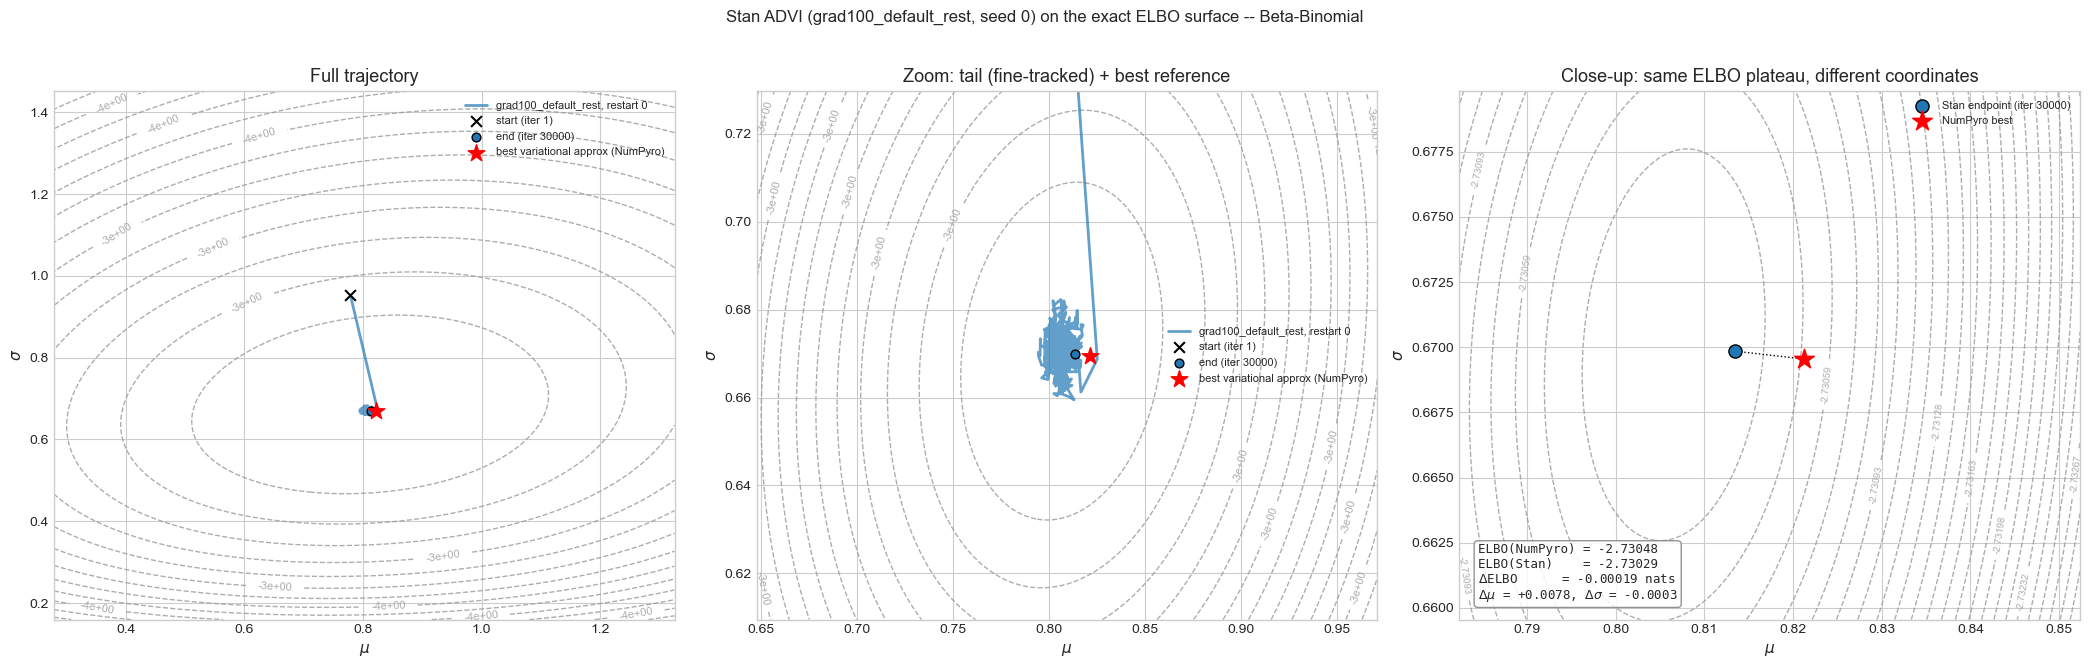

In [7]:
# --- plot: full path, a zoom on the tail + reference point, and an ultra-close-up
# --- showing how close the two points are in ELBO despite the coordinate gap ---

def make_grid(mu_lim, sigma_lim, n=200):
    mu_vals = np.linspace(*mu_lim, n)
    sigma_vals = np.linspace(*sigma_lim, n)
    Mu, Sigma = np.meshgrid(mu_vals, sigma_vals)
    Z = elbo(Mu, Sigma)
    return Mu, Sigma, Z


mu_end, sigma_end = float(traj_mu[-1]), float(traj_sigma[-1])
elbo_star = float(elbo(np.array([mu_star]), np.array([sigma_star]))[0])
elbo_end = float(elbo(np.array([mu_end]), np.array([sigma_end]))[0])
print(f"ELBO(NumPyro best)  = {elbo_star:.6f}")
print(f"ELBO(Stan endpoint) = {elbo_end:.6f}")
print(f"Delta ELBO (= Delta KL to true posterior, nats) = {elbo_star - elbo_end:+.6f}")

pad = 0.5
full_mu_lim = (min(traj_mu.min(), mu_star) - pad, max(traj_mu.max(), mu_star) + pad)
full_sigma_lim = (max(min(traj_sigma.min(), sigma_star) - pad, 1e-3), max(traj_sigma.max(), sigma_star) + pad)

tail = slice(len(traj_iters) * 2 // 3, None)
zoom_pad_mu = max(0.15, 3 * traj_mu[tail].std())
zoom_pad_sigma = max(0.05, 3 * traj_sigma[tail].std())
zoom_mu_lim = (
    min(traj_mu[tail].min(), mu_star) - zoom_pad_mu,
    max(traj_mu[tail].max(), mu_star) + zoom_pad_mu,
)
zoom_sigma_lim = (
    max(min(traj_sigma[tail].min(), sigma_star) - zoom_pad_sigma, 1e-3),
    max(traj_sigma[tail].max(), sigma_star) + zoom_pad_sigma,
)

# close-up window: just big enough to comfortably contain both points with margin,
# so the level curves drawn from THIS tiny local ELBO range are fine enough to show
# the plateau, instead of being swamped by the much larger range in the other panels.
dmu = abs(mu_star - mu_end)
dsigma = abs(sigma_star - sigma_end)
pad_mu = max(4 * dmu, 0.01)
pad_sigma = max(4 * dsigma, 0.01)
close_mu_lim = (min(mu_star, mu_end) - pad_mu, max(mu_star, mu_end) + pad_mu)
close_sigma_lim = (min(sigma_star, sigma_end) - pad_sigma, max(sigma_star, sigma_end) + pad_sigma)

fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))

for ax, mu_lim, sigma_lim, title, every in (
    (axes[0], full_mu_lim, full_sigma_lim, "Full trajectory", 1),
    (axes[1], zoom_mu_lim, zoom_sigma_lim, "Zoom: tail (fine-tracked) + best reference", 1),
):
    Mu, Sigma, Z = make_grid(mu_lim, sigma_lim)
    levels = np.linspace(Z.min(), Z.max(), 15)
    draw_contours(ax, Mu, Sigma, Z, levels, title, r"$\mu$", r"$\sigma$")

    draw_trajectory(ax, traj_mu, traj_sigma, color="tab:blue", label="grad100_default_rest, restart 0", every=every)
    ax.scatter(traj_mu[0], traj_sigma[0], marker="x", color="black", s=60, linewidths=1.5, zorder=6, label="start (iter 1)")
    ax.scatter(mu_end, sigma_end, color="tab:blue", s=40, edgecolors="black", zorder=6, label=f"end (iter {traj_iters[-1]})")
    ax.scatter(mu_star, sigma_star, marker="*", color="red", s=160, zorder=7, label="best variational approx (NumPyro)")

    ax.set_xlim(mu_lim)
    ax.set_ylim(sigma_lim)
    ax.legend(loc="best", fontsize=8)

# --- close-up panel ---
ax = axes[2]
Mu, Sigma, Z = make_grid(close_mu_lim, close_sigma_lim, n=300)
levels = np.linspace(Z.min(), Z.max(), 25)
contour_kwargs = {"levels": levels, "colors": "0.6", "linestyles": "dashed", "linewidths": 1.0, "alpha": 0.8}
cs = ax.contour(Mu, Sigma, Z, **contour_kwargs)
ax.clabel(cs, levels[::3], fmt=lambda v: f"{v:.5f}", fontsize=7)
ax.set_title("Close-up: same ELBO plateau, different coordinates")
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\sigma$")

ax.scatter(mu_end, sigma_end, color="tab:blue", s=90, edgecolors="black", zorder=6, label=f"Stan endpoint (iter {traj_iters[-1]})")
ax.scatter(mu_star, sigma_star, marker="*", color="red", s=220, zorder=7, label="NumPyro best")
ax.plot([mu_star, mu_end], [sigma_star, sigma_end], color="black", linestyle=":", linewidth=1.0, zorder=5)

annotation = (
    f"ELBO(NumPyro) = {elbo_star:.5f}\n"
    f"ELBO(Stan)    = {elbo_end:.5f}\n"
    f"$\\Delta$ELBO      = {elbo_star - elbo_end:+.5f} nats\n"
    f"$\\Delta\\mu$ = {mu_star - mu_end:+.4f}, $\\Delta\\sigma$ = {sigma_star - sigma_end:+.4f}"
)
ax.text(
    0.03, 0.03, annotation, transform=ax.transAxes, fontsize=9,
    verticalalignment="bottom", family="monospace",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="0.5"),
)
ax.set_xlim(close_mu_lim)
ax.set_ylim(close_sigma_lim)
ax.legend(loc="upper right", fontsize=8)

fig.suptitle("Stan ADVI (grad100_default_rest, seed 0) on the exact ELBO surface -- Beta-Binomial", y=1.02)
fig.tight_layout()
plt.show()

## What to look for

- The **left panel** shows the whole path from the initial point (`x`) through to the end
  of the 30,000-iteration budget, on top of the exact ELBO surface for this model.
- The **middle panel** zooms into the last third of tracked checkpoints (the densely-tracked
  tail) alongside the best-recorded reference point (red star).
- The **right panel** zooms all the way in to just the two points of interest, with contour
  levels drawn from *that* tiny local ELBO range (not the wider range in the other panels) --
  so the near-flat plateau they both sit on is actually visible as level curves, and the
  annotation gives the exact numbers: despite a real gap in `(mu, sigma)` coordinates, the
  ELBO values themselves (equivalently, KL divergence to the true posterior) are essentially
  identical. That's the "different target" effect from the mean-band plots made concrete --
  Stan's own optimizer settles at a different point on a fairly flat part of the ELBO surface
  than NumPyro's did, not because it's worse, but because the surface doesn't strongly
  distinguish nearby points near this optimum.
- Because `output_samples=20,000` was used for every checkpoint here (vs. the pipeline's
  default 1,000), any wiggle remaining in the tail is predominantly Stan's own optimizer
  behavior, not reconstruction noise from too few draws.